In [35]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
Housing_df = pd.read_csv('../data/USA_Housing.csv')
Housing_df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [5]:
Housing = Housing_df.iloc[:,:-1]
Housing.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05


## Divide into Features and Target

In [6]:
X = Housing.iloc[:,:-1]
X.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
0,79545.458574,5.682861,7.009188,4.09,23086.800503
1,79248.642455,6.002900,6.730821,3.09,40173.072174
2,61287.067179,5.865890,8.512727,5.13,36882.159400
3,63345.240046,7.188236,5.586729,3.26,34310.242831
4,59982.197226,5.040555,7.839388,4.23,26354.109472


In [8]:
y = Housing.iloc[:,-1]
y.head()

0    1.059034e+06
1    1.505891e+06
2    1.058988e+06
3    1.260617e+06
4    6.309435e+05
Name: Price, dtype: float64

## Split into test and training data.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Train/Fit the training Data

In [10]:
lm = LinearRegression()

In [22]:
lm.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Coefficients after training

In [23]:
lm.coef_

array([2.16522058e+01, 1.64666481e+05, 1.19624012e+05, 2.44037761e+03,
       1.52703134e+01])

In [21]:
coef_df = pd.DataFrame(lm.coef_, index=X.columns, columns=['Coefficients'])
coef_df

,Coefficients
Avg. Area Income,21.652206
Avg. Area House Age,164666.480722
Avg. Area Number of Rooms,119624.012232
Avg. Area Number of Bedrooms,2440.377611
Area Population,15.270313


In [24]:
lm.intercept_

-2635072.900933357

## Test the model for predictions

In [26]:
y_pred = lm.predict(X_test)
y_pred

array([1308587.92699759, 1237037.22949434, 1243429.34030681,
       1228900.2136037 , 1063320.9071083 , 1544058.05034861,
       1094774.70493019,  833284.72339225,  788412.85578719,
       1469714.86615709,  671728.43662062, 1606818.21977961,
       1004166.61331065, 1796798.9759592 , 1288566.96221026,
       1087782.93301076, 1423072.37492533, 1078178.68169677,
        802286.03537898,  930761.0369571 , 1134829.86477822,
        916398.42023144, 1489972.69335433, 1284580.15538816,
       1582071.35322737, 1132519.15991992, 1089888.39644517,
        974510.51872155,  924057.96820648, 1740759.72092282,
       1286481.59512311, 1621289.95171608, 1435264.2016172 ,
       1234014.77924477, 1485434.57300368, 1718335.00753702,
       1538953.74882858,  777106.64791791, 1765201.5224362 ,
       1175972.14199818, 1553707.94323485,  897703.67505179,
       1371049.80326609,  845281.72310359, 1201022.89803887,
       1133285.98450866, 1363128.14557346, 1449814.08768277,
       1574363.90467358,

## Evaluate the model.

In [29]:
print(f'MAE : {mean_absolute_error(y_test, y_pred)}')
print(f'MSE : {mean_squared_error(y_test, y_pred)}')
print(f'RMSE : {np.sqrt(mean_squared_error(y_test, y_pred))}')
print(f'R2_SCORE : {r2_score(y_test, y_pred)}')

MAE : 80879.09723489822
MSE : 10089009300.894522
RMSE : 284.39250558848806
R2_SCORE : 0.9179971706834288


In [31]:
Residuals = y_test - y_pred

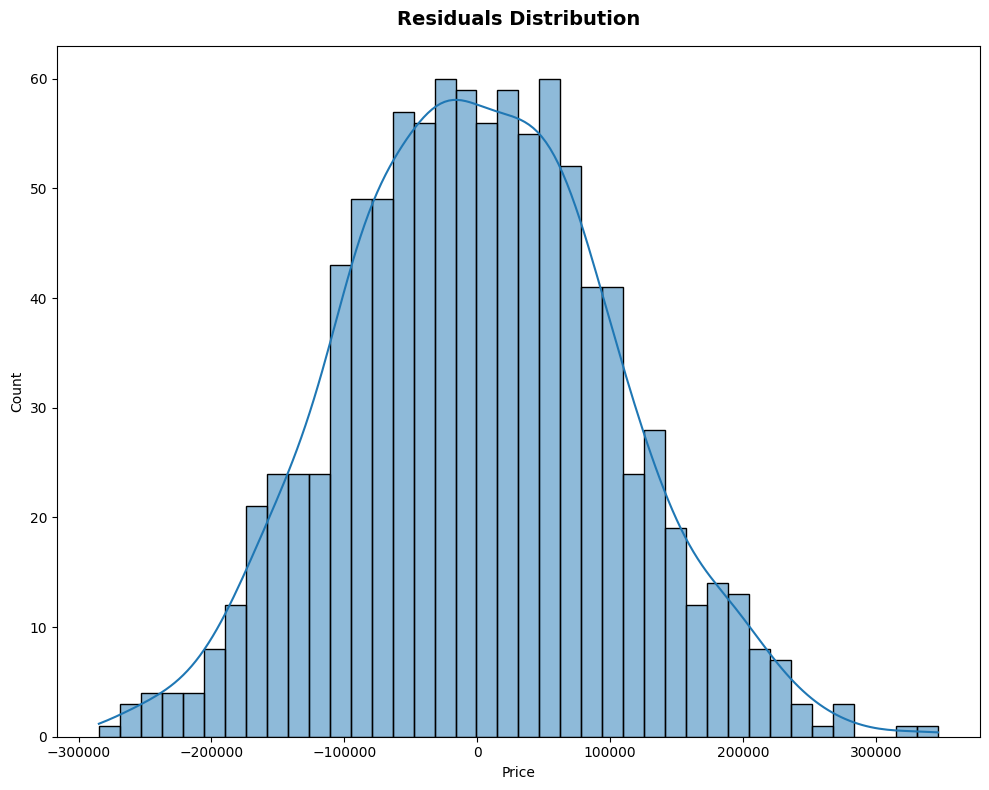

In [41]:
plt.figure(figsize=(10,8))
sns.histplot(Residuals, kde=True, bins=40)
plt.title('Residuals Distribution', fontsize=14, weight='bold', pad=15)

plt.tight_layout()
plt.savefig('../reports/figures/Residuals_dist.png')

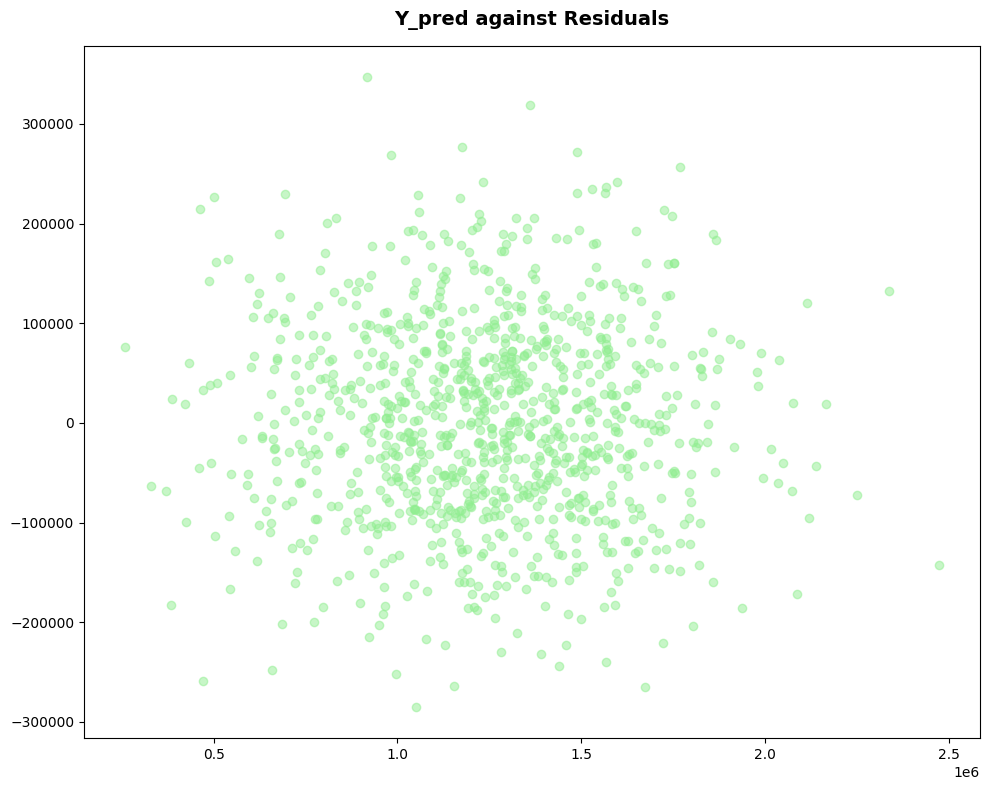

In [48]:
plt.figure(figsize=(10,8))
plt.scatter(y_pred, Residuals, color='lightgreen', alpha=0.5)
plt.title('Y_pred against Residuals', fontsize=14, weight='bold', pad=15)

plt.tight_layout()
plt.savefig('../reports/figures/Y_pred_vs_residuals.png')

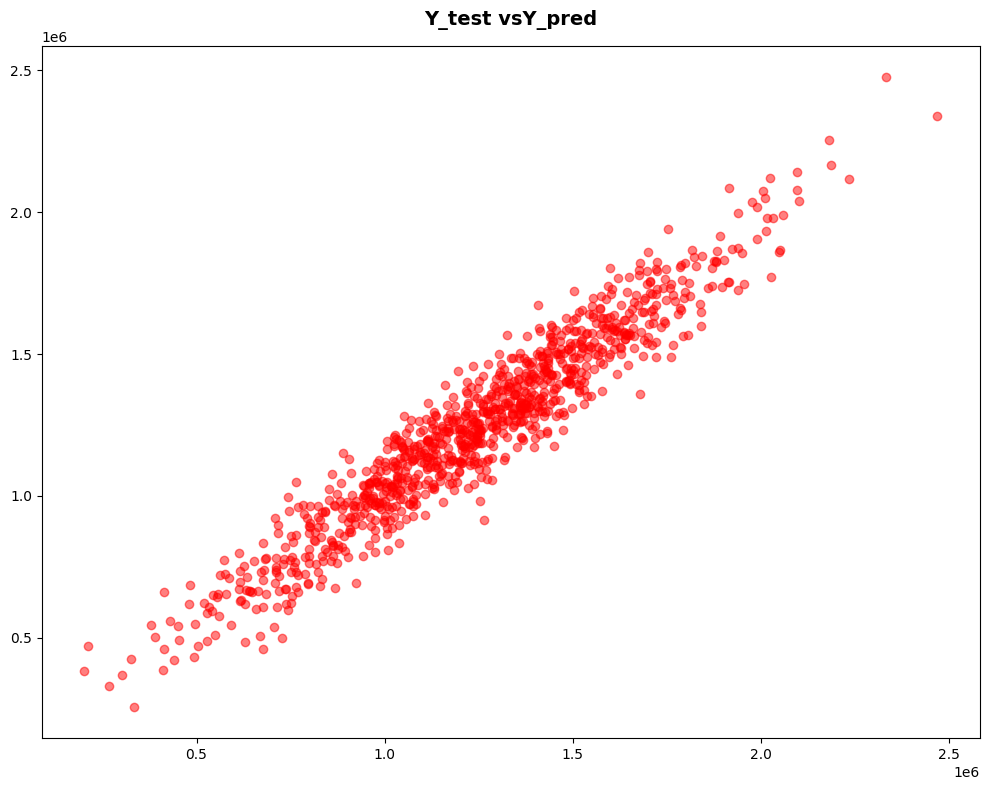

In [54]:
plt.figure(figsize=(10,8))
plt.scatter(y_test, y_pred, color='red', alpha=0.5)
plt.title('Y_test vsY_pred', fontsize=14, weight='bold', pad=15)

plt.tight_layout()
plt.savefig('../reports/figures/Y_test_vs_Y_pred.png')